## Tensor Networks Fopra  Day 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from a_mps import *
from b_model import *
from c_tebd import *

In [27]:
"Part 4.1a"

L = 14
mp = init_spinup_MPS(L)
sigma_z = [[1, 0],[0, -1]]
sigma_x = [[0, 1], [1, 0]]
sigma_y = [[0, -1.j], [1.j, 0]]
print("sigma_x expectation values are:", mp.site_expectation_value(sigma_x))
print("sigma_y expectation values are:", mp.site_expectation_value(sigma_y))
print("sigma_z expectation values are:", mp.site_expectation_value(sigma_z))


sigma_x expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sigma_y expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sigma_z expectation values are: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [28]:
"Part 4.1b"

def init_plus_MPS(L):
    """Return a product state with all spins right as an MPS"""
    B = np.zeros([1, 2, 1], float)
    B[0, 0, 0] = 1/np.sqrt(2)
    B[0, 1, 0] = 1/np.sqrt(2)
    S = np.ones([1], float)
    Bs = [B.copy() for i in range(L)]
    Ss = [S.copy() for i in range(L)]
    return MPS(Bs, Ss)

L = 14
mp = init_plus_MPS(L)
sigma_z = [[1, 0],[0, -1]]
sigma_x = [[0, 1], [1, 0]]
sigma_y = [[0, -1.j], [1.j, 0]]
print("sigma_x expectation values are:", mp.site_expectation_value(sigma_x))
print("sigma_y expectation values are:", mp.site_expectation_value(sigma_y))
print("sigma_z expectation values are:", mp.site_expectation_value(sigma_z))

sigma_x expectation values are: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
sigma_y expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sigma_z expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [4]:
"Part 4.1b"

def init_plus_MPS(L):
    """Return a product state with all spins right as an MPS"""
    B = np.zeros([1, 2, 1], float)
    B[0, 0, 0] = 1/np.sqrt(2)
    B[0, 1, 0] = 1/np.sqrt(2)
    S = np.ones([1], float)
    Bs = [B.copy() for i in range(L)]
    Ss = [S.copy() for i in range(L)]
    return MPS(Bs, Ss)

L = 14
mp = init_plus_MPS(L)
sigma_z = [[1, 0],[0, -1]]
sigma_x = [[0, 1], [1, 0]]
sigma_y = [[0, -1.j], [1.j, 0]]
print("sigma_x expectation values are:", mp.site_expectation_value(sigma_x))
print("sigma_y expectation values are:", mp.site_expectation_value(sigma_y))
print("sigma_z expectation values are:", mp.site_expectation_value(sigma_z))

sigma_x expectation values are: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
sigma_y expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
sigma_z expectation values are: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


For g =  0.5  and for the spin-up state E =  -7.0
For g =  0.5  and for the plus state E =  -12.999999999999996
For g =  1  and for the spin-up state E =  -14.0
For g =  1  and for the plus state E =  -12.999999999999996
For g =  1.5  and for the spin-up state E =  -21.0
For g =  1.5  and for the plus state E =  -12.999999999999996


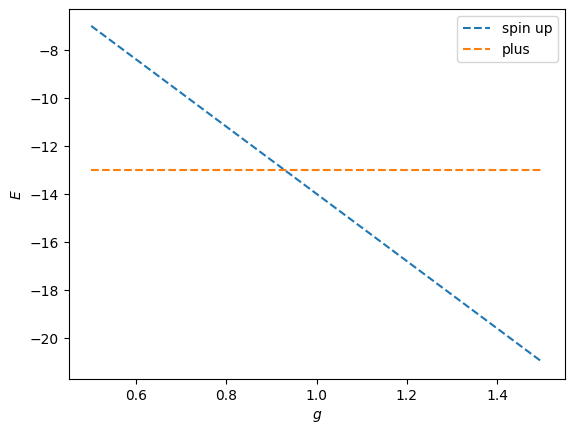

In [29]:
"Part 4.1c"

L = 14
J = 1
gs = [0.5, 1, 1.5]
mp_spinup = init_spinup_MPS(L)
mp_plus = init_plus_MPS(L)
energies_spinup = {}
energies_plus = {}
import matplotlib.pyplot as plt

for g in gs:
  tfi = TFIModel(L, J, g)
  energies_spinup[g] = tfi.energy(mp_spinup)
  energies_plus[g] = tfi.energy(mp_plus)

  print("For g = ", g, " and for the spin-up state E = ", tfi.energy(mp_spinup))
  print("For g = ", g, " and for the plus state E = ", tfi.energy(mp_plus))

plt.plot(gs, energies_spinup.values(), linestyle="--",label=r'spin up')
plt.plot(gs, energies_plus.values(), linestyle="--", label='plus')
plt.xlabel(r'$g$')
plt.ylabel(r'$E$')
plt.legend()

In [6]:
class TLFIModel(TFIModel):
    """Class generating the Hamiltonian of the transverse-field Ising model.

    The Hamiltonian reads
    .. math ::
        H = - J \\sum_{i} \\sigma^x_i \\sigma^x_{i+1} - g \\sum_{i} \\sigma^z_i

    Parameters
    ----------
    L : int
        Number of sites.
    J, g : float
        Coupling parameters of the above defined Hamiltonian.

    Attributes
    ----------
    L : int
        Number of sites.
    d : int
        Local dimension (=2 for spin-1/2 of the transverse field ising model)
    sigmax, sigmay, sigmaz, id :
        Local operators, namely the Pauli matrices and identity.
    H_bonds : list of np.Array[ndim=4]
        The Hamiltonian written in terms of local 2-site operators, ``H = sum_i H_bonds[i]``.
        Each ``H_bonds[i]`` has (physical) legs (i out, (i+1) out, i in, (i+1) in),
        in short ``i j i* j*``.
    """

    def __init__(self, L, J, g, h):
        self.L, self.d = L, 2
        self.J, self.g, self.h = J, g, h
        self.sigmax = np.array([[0., 1.], [1., 0.]])
        self.sigmay = np.array([[0., -1j], [1j, 0.]])
        self.sigmaz = np.array([[1., 0.], [0., -1.]])
        self.id = np.eye(2)
        self.init_H_bonds()

    def init_H_bonds(self):
        """Initialize `H_bonds` hamiltonian. Called by __init__()."""
        sx, sz, id = self.sigmax, self.sigmaz, self.id
        d = self.d
        H_list = []
        for i in range(self.L - 1):
            gL = gR = 0.5 * self.g
            hL = hR = 0.5 * self.h
            if i == 0: # first bond
                gL = self.g
                hL = self.h
            if i + 1 == self.L - 1: # last bond
                gR = self.g
                hR = self.h
            H_bond = -self.J * np.kron(sx, sx) - gL * np.kron(sz, id) - gR * np.kron(id, sz) - hL * np.kron(sx, id) - hR * np.kron(id, sx)
            # H_bond has legs ``i, j, i*, j*``
            H_list.append(np.reshape(H_bond, [d, d, d, d]))
        self.H_bonds = H_list

    def energy(self, psi):
        """Evaluate energy E = <psi|H|psi> for the given MPS."""
        assert psi.L == self.L
        return np.sum(psi.bond_expectation_value(self.H_bonds))

In [7]:
"Part 4.2a"

def correlation(psi: MPS, X, Y, i):
  correlations = []
  theta_i = psi.get_theta1(i)
  contr = np.array(X)@np.array(Y) # pU, pD
  contr = np.tensordot(theta_i, contr, axes =[[1], [0]]) #vL, vR, pD
  contr = np.tensordot(contr, np.conj(theta_i), axes=[[0, 2, 1],[0, 1, 2]])
  correlations.append(contr.item())

  environment = np.tensordot(theta_i, X, axes=[[1],[0]]) #vL, vR, pD
  environment = np.tensordot(environment, np.conj(theta_i), axes=[[0, 2],[0, 1]]) #vR1, vR2
  for j in range(i+1, psi.L):
    beta_current = psi.Bs[j]
    environment = np.tensordot(environment, beta_current, axes=[[0],[0]]) # vR2, pD, vR1
    environment = np.tensordot(environment, np.conj(beta_current), axes = [[0],[0]]) # pD, vR1, pU, vR2
    temp = np.tensordot(environment, Y, axes = [[0, 2], [0, 1]]) # vR1, vR2
    trace = np.trace(temp, axis1=0, axis2=1)
    correlations.append(np.real_if_close(trace))
    environment = np.trace(environment, axis1=0, axis2=2)

  return correlations


finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.30
dt = 0.10000: E = -29.7237778057965
dt = 0.01000: E = -29.7243442589172
dt = 0.00100: E = -29.7244030096187
dt = 0.00010: E = -29.7244089062471
dt = 0.00001: E = -29.7244094959373
final bond dimensions:  [2, 4, 8, 12, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 12, 8, 4, 2]
[1.0000000000000002, array(0.97710707), array(0.97671366), array(0.97669885), array(0.97669811), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669807), array(0.97669806), array(0.97669798), array(0.97669701), array(0.97668503), array(0.97653098), array(0.9744692), array(0.94277192)]
finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.50
dt = 0.10000: E = -31.0307109228222
dt = 0.01000: E = -31.0351587180616
dt = 0.00100: E = -31.0356104605838
dt = 0.00010: E = -

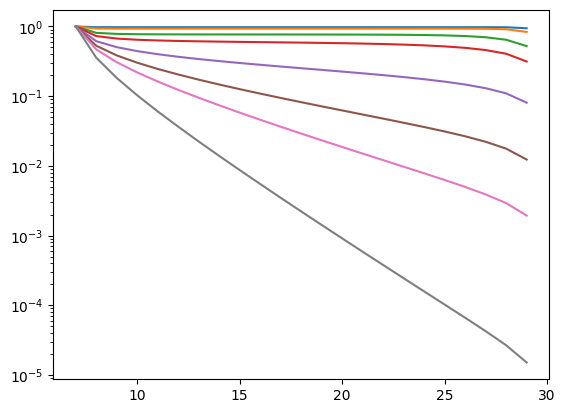

In [8]:
"Part 4.2b"

L=30
J=1

def example_TEBD_gs_finite(L, J, g):
    print("finite TEBD, (imaginary time evolution)")
    print("L={L:d}, J={J:.1f}, g={g:.2f}".format(L=L, J=J, g=g))
    #import a_mps
    #import b_model
    model = TFIModel(L, J=J, g=g)
    psi = init_spinup_MPS(L)
    for dt in [0.1, 0.01, 0.001, 1.e-4, 1.e-5]:
        U_bonds = calc_U_bonds(model, dt)
        run_TEBD(psi, U_bonds, N_steps=500, chi_max=100, eps=1.e-10)
        E = model.energy(psi)
        print("dt = {dt:.5f}: E = {E:.13f}".format(dt=dt, E=E))
    print("final bond dimensions: ", psi.get_chi())
    return E, psi, model

def TEBD_gs_finite_correlations(L, J, g):
    print("finite TEBD, (imaginary time evolution)")
    print("L={L:d}, J={J:.1f}, g={g:.2f}".format(L=L, J=J, g=g))
    model = TFIModel(L=L, J=J, g=g)
    psi = init_spinup_MPS(L)
    dt = 1.e-5
    U_bonds = calc_U_bonds(model, dt)
    run_TEBD(psi, U_bonds, N_steps=1000, chi_max=100, eps=1.e-10)
    E = model.energy(psi)
    print("dt = {dt:.5f}: E = {E:.13f}".format(dt=dt, E=E))


    return E, psi, model

gs = [0.3, 0.5, 0.8, 0.9, 1., 1.1, 1.2, 1.5]
energies = []
correlations = {}
x_axis = np.arange(L//4, L)
for g in gs:
  E, psi, model = example_TEBD_gs_finite(L=L, J=J, g=g)
  energies.append(E)
  correlations[g] = correlation(psi, sigma_x, sigma_x, L//4)
  plt.plot(x_axis, (correlations[g]))

  print(correlations[g])
plt.yscale('log')
plt.show()


finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.30
dt = 0.10000: E = -29.7237778057965
dt = 0.01000: E = -29.7243442589172
final bond dimensions:  [2, 4, 8, 12, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 12, 8, 4, 2]
[np.float64(0.9882786163051127)]
finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.50
dt = 0.10000: E = -31.0307109228222
dt = 0.01000: E = -31.0351587180616
final bond dimensions:  [2, 4, 8, 14, 18, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 18, 14, 8, 4, 2]
[np.float64(0.9882786163051127), np.float64(0.9645728715632862)]
finite TEBD, (imaginary time evolution)
L=30, J=1.0, g=0.80
dt = 0.10000: E = -34.3536078657672
dt = 0.01000: E = -34.3864798964379
final bond dimensions:  [2, 4, 8, 16, 22, 28, 32, 34, 34, 36, 36, 36, 38, 40, 40, 40, 38, 36, 36, 36, 34, 34, 32, 28, 22, 16, 8, 4, 2]
[np.float64(0.9882786163051127), np.float64(0.9645728715632862), np.float64(0.8631247522085992)]
fini

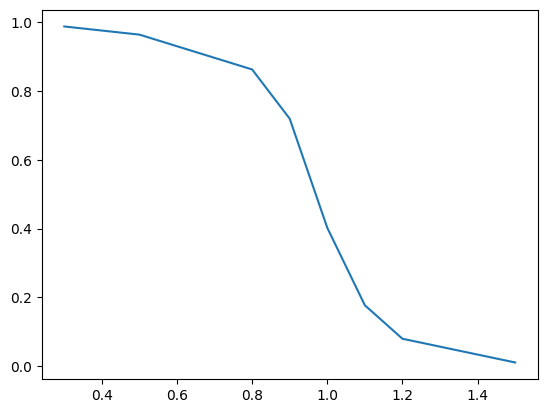

In [9]:
L=30
J=1

def example_TEBD_gs_finite(L, J, g):
    print("finite TEBD, (imaginary time evolution)")
    print("L={L:d}, J={J:.1f}, g={g:.2f}".format(L=L, J=J, g=g))
    #import a_mps
    #import b_model
    model = TFIModel(L, J=J, g=g)
    psi = init_spinup_MPS(L)
    for dt in [0.1, 0.01]:
        U_bonds = calc_U_bonds(model, dt)
        run_TEBD(psi, U_bonds, N_steps=500, chi_max=100, eps=1.e-10)
        E = model.energy(psi)
        print("dt = {dt:.5f}: E = {E:.13f}".format(dt=dt, E=E))
    print("final bond dimensions: ", psi.get_chi())
    return E, psi, model


gs = [0.3, 0.5, 0.8, 0.9, 1., 1.1, 1.2, 1.5]
energies = []
correlations = {}
x_axis = np.arange(L//4, L)
magnetisation = []
for g in gs:
  E, psi, model = example_TEBD_gs_finite(L=L, J=J, g=g)
  energies.append(E)
  correlations[g] = correlation(psi, sigma_x, sigma_x, L//4)
  magnetisation.append(np.sqrt(correlations[g][5*L//8]))
  print(magnetisation)

plt.plot(gs, magnetisation)
plt.show()

## Day 2

In [ ]:
# Calculates correlation functions of the form <psi| Op1(t) Op2(0) |psi>
# This method also time evolves the state
def calc_correlations(model, psi, op1, op2, i, j, dt=0.1, N_steps=100, chi_max=30, eps=1e-10):
    # Raising and lowering operator do not preserve canonical form, nor norm!
    # After _matvec multiplication, the reconstruction of the canonical form and normalization is generally required!  
    print("Calculating Dynamical correlation functions...")
    print(f"System Size: {model.L}, Total time: {dt * N_steps}")
    correlations = {}
    U_bonds = c_tebd.calc_U_bonds(model, 1.j * dt)
    ket = deepcopy(psi)
    ket = _matvec(op2, ket, j)
    norm_correction = np.sqrt(mps_overlap(ket, ket))  # ||S+|psi>||
    for step in range(N_steps + 1):
        t = step * dt
        print(f"  t = {t}")
        ket_tmp = deepcopy(ket)
        ket_tmp = _matvec(op1, ket_tmp, i) 
        val = mps_overlap(psi, ket_tmp)
        if step > 0:
            val *= norm_correction
        correlations[t] = val
        # Time evolve for next step
        if step < N_steps:
            c_tebd.run_TEBD(ket, U_bonds, 1, chi_max, eps)  
    return correlations


model = TLFI(L, J ,g, h)


In [ ]:
class MPS_modified (MPS):
    __matmul(self, other)__:
        

0.9999999999999978

In [38]:
mps_overlap(mp_spinup, mp_spinup)

1.0

In [37]:
import a_mps 

#  Function to calculate the overlap of two MPS
def mps_overlap(bra: a_mps.MPS, ket: a_mps.MPS):
    assert bra.L == ket.L
    L = bra.L
    env= np.array([[1.0]]) # vR vR*
    for n in range(L):      
        B_bra = bra.get_theta1(n).conj() if n == 0 else bra.Bs[n].conj() # vL* i* vR*
        B_ket = ket.get_theta1(n).conj() if n == 0 else ket.Bs[n] # vL i vR
        env = np.tensordot(env, B_ket, axes=(0, 0)) # vR* i vR
        env = np.tensordot(env, B_bra, axes=[(0, 1), (0, 1)]) # vR vR*
    return env.item()

In [39]:
mps_overlap(mp_spinup, mp_plus)

0.007812499999999991

# Fourier

(201,) (30, 201)


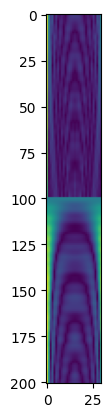

In [ ]:
import numpy as np
from numpy import fft
import matplotlib.pyplot as plt
arr = np.load('kurcina.npy')

# 0.5, 200
N=200
dt=0.5
L=30
tns = np.array(range(N+1))
def G(tn, N = 200):
    return np.exp(-0.5*tn / (0.5*N))

Gs = G(tns)
print(Gs.shape, arr.shape) # (201,) (30, 201)

Fourier_set = arr.T * Gs[:, None]
#print(Fourier_set.shape) # *(201, 30)
S_omega = fft.fft(Fourier_set, axis=0)
S_omega = fft.fftshift(S_omega, axes=0)
omega_vals = fft.fftfreq(N, dt) * 2 * np.pi 
#omega_vals = fft.fftshift(omega_vals)
S_k_omega = fft.fftshift(fft.fft(Fourier_set, axis=1), axes=0)

k_vals = fft.fftfreq(L, 1) * 2 * np.pi
k_vals = fft.fftshift(k_vals)


plt.imshow(np.abs(S_k_omega))
#S_q_omega = fft.fft(S_k_omega, axis=0)
#k_vals = fft.fftfreq(L, 1) * 2 * np.pi
#S_q_omega = fft.fftshift(S_q_omega, axes=0)  # Shift to center

#plt.figure(figsize=(8, 6))
#plt.imshow(np.abs(S_q_omega), aspect='auto', origin='lower', extent=[k_vals[0], k_vals[-1], omega_vals[0], omega_vals[-1]])
#plt.colorbar(label='Amplitude')
#plt.xlabel('k (Wave number)')
##plt.ylabel('ω (Frequency)')
#plt.title('2D Fourier Transform S(k, ω)')
#plt.show()

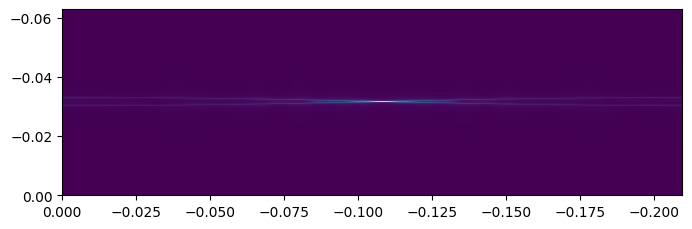

In [58]:
trans = fft.fftshift(Fourier_set)
trans = fft.fft2(Fourier_set)
trans = np.abs(trans)
trans = fft.fftshift(trans)
omega_vals = fft.fftfreq(N, dt) * 2 * np.pi 
k_vals = fft.fftfreq(L, 1) * 2 * np.pi


plt.figure(figsize=(8, 6))

plt.imshow(trans, extent=[k_vals[0], k_vals[-1], omega_vals[0], omega_vals[-1]])

In [60]:
def get_spectral_function(L, J, g, h, dt, t_max, chi_max=30, eps=1e-10):
    E0, psi_0, model = get_groundstate(L, J, g, h, chi_max)
   # 
    print('-'*70)
    print('Compute dynamic correlations')
    corrs, entanglement = compute_dynamic_correlations(psi_0, model, E0, dt, t_max, chi_max, eps)
    Ctx = corrs
    
    # Rearrange corrs such that position 0 corresponds to the perturbed site
    # (distance 0 to perturbation)
    xi = L//2
    c_temp = np.zeros(corrs.shape, dtype=complex)
    c_temp[:, :L-xi] = corrs[:, xi:]
    c_temp[:, L-xi:] = corrs[:, :xi]
    corrs = c_temp
    
    print('Compute Fourier transform')
    # Fourier transform in space
    corrs_tk = np.zeros((corrs.shape[0], corrs.shape[1]+1), dtype=complex)
    for i in np.arange(corrs.shape[0]):
        momenta, Ck = fourier_space(corrs[i,:])
        corrs_tk[i, :] = Ck
        
    # Fourier transform in time
    Swk = np.zeros(corrs_tk.shape, dtype=complex)
    for k in np.arange(corrs_tk.shape[1]):
        freqs, Sw = fourier_time(corrs_tk[:, k], dt)
        Swk[:, k] = Sw
    print('finished')
    
    return np.array(Swk), momenta, freqs, Ctx, entanglement


def fourier_space(x_series):
    """ Calculates the FFT of a spatial series of values. """
    import numpy as np
    ft = np.fft.fft(x_series)
    n = len(x_series)
    momenta = 2*np.pi * np.fft.fftfreq(n, 1)
    
    # order momenta in increasing order
    momenta = np.fft.fftshift(momenta)
    
    # shift results accordingly
    Ck = np.fft.fftshift(ft)
    
    # extend the results to the whole Brillouin zone (right border included)
    momenta = np.append(momenta, -momenta[0])
    Ck = np.append(Ck, Ck[0])
    
    return momenta, Ck

def fourier_time(t_series, dt, sigma = 0.4):
    """ Calculates the FFT of a time series, applying a Gaussian window function. """
    
    # Gaussian window function
    n = len(t_series)
    gauss = [np.exp(-1/2.*(i/(sigma * n))**2) for i in np.arange(n)]
    input_series = gauss * t_series
    
    # Fourier transform
    ft = np.fft.fft(input_series)
    freqs = np.fft.fftfreq(n, dt) * 2 * np.pi
    
    # order frequencies in increasing order
    end = np.argmin(freqs)
    freqs = np.append(freqs[end:], freqs[:end])
    # shift results accordingly
    ftShifted = np.append(ft[end:], ft[:end])
    
    # Take into account the additional minus sign in the time FT
    if len(ftShifted)%2 == 0:
        ftShifted = np.append(ftShifted, ftShifted[0])
        ftShifted = ftShifted[::-1]
        ftShifted = ftShifted[:-1]
    else:
        ftShifted = ftShifted[::-1]
        
    return freqs, ftShifted

In [66]:
[fourier_time(arr[:][i], dt) for i in range(len(arr[0])-1)]

IndexError: index 30 is out of bounds for axis 0 with size 30

In [73]:
freqs, ftshifted = [fourier_time(arr.T[i], dt) for i in range(N)]
ks, ftkshifted = [fourier_space(arr[i]) for i in range(L)]

print(np.array(freqs).shape, np.array(ks).shape)

ValueError: too many values to unpack (expected 2)

In [61]:
arr.shape

(30, 201)